In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

data_dir = Path().resolve().parent / 'data'

sales = pd.read_csv(data_dir / 'sales_history.csv')
stock = pd.read_csv(data_dir / 'stock_history.csv')
promos = pd.read_csv(data_dir / 'promo_calendar.csv')
items = pd.read_csv(data_dir / 'item_master.csv')

# Full merge
df_full = (
    sales
    .merge(stock, on=['sku', 'location', 'period'], how='left')
    .merge(promos, on=['sku', 'period'], how='left')
    .merge(items, on=['sku'], how='left')
)

# Fill structural missing values for merged features
df_full['days_out_of_stock'] = df_full['days_out_of_stock'].fillna(0)
df_full['discount_pct'] = df_full['discount_pct'].fillna(0)

print("Full Merged Dataset Head")
display(df_full.head(20))

Full Merged Dataset Head


,sku,location,period,qty,stock_end_qty,days_out_of_stock,promo_type,discount_pct,category,abc_class,launch_period,predecessor_sku,uom
0,SKU_0001,MSK,2023-01,243,174,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
1,SKU_0001,MSK,2023-02,179,150,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
2,SKU_0001,MSK,2023-03,168,193,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
3,SKU_0001,MSK,2023-04,204,232,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
4,SKU_0001,MSK,2023-05,153,199,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
5,SKU_0001,MSK,2023-06,226,126,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
6,SKU_0001,MSK,2023-07,283,503,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
7,SKU_0001,MSK,2023-08,290,153,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
8,SKU_0001,MSK,2023-09,268,141,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS
9,SKU_0001,MSK,2023-10,330,135,0,NaN,0.0,SNACK,B,2023-01,NaN,PCS


In [24]:
print("SALES HISTORY")
display(sales.head())
print(f"Total records {len(sales)}")
print(f"Unique SKUs {sales['sku'].nunique()}")
print("")

print("STOCK HISTORY")
display(stock.head())
print(f"Total records {len(stock)}")
print(f"Records with Out of Stock days {len(stock[stock['days_out_of_stock'] > 0])}")
print("")

print("PROMO CALENDAR")
display(promos.head())
print(f"Total records {len(promos)}")
if 'promo_type' in promos.columns:
    print("Promo types distribution")
    display(promos['promo_type'].value_counts(dropna=False))
if 'discount_pct' in promos.columns:
    print("Discount percentage distribution")
    display(promos['discount_pct'].value_counts(dropna=False))
print("")

print("ITEM MASTER")
display(items.head())
print(f"Total records {len(items)}")
if 'abc_class' in items.columns:
    print("ABC class distribution")
    display(items['abc_class'].value_counts(dropna=False))
if 'predecessor_sku' in items.columns:
    missing_predecessors = items['predecessor_sku'].isna().sum()
    print(f"Items without predecessor SKU {missing_predecessors} out of {len(items)}")

SALES HISTORY


,sku,location,period,qty
0,SKU_0001,MSK,2023-01,243
1,SKU_0001,MSK,2023-02,179
2,SKU_0001,MSK,2023-03,168
3,SKU_0001,MSK,2023-04,204
4,SKU_0001,MSK,2023-05,153


Total records 1526
Unique SKUs 40

STOCK HISTORY


,sku,location,period,stock_end_qty,days_out_of_stock
0,SKU_0001,MSK,2023-01,174,0
1,SKU_0001,MSK,2023-02,150,0
2,SKU_0001,MSK,2023-03,193,0
3,SKU_0001,MSK,2023-04,232,0
4,SKU_0001,MSK,2023-05,199,0


Total records 1523
Records with Out of Stock days 10

PROMO CALENDAR


...


ITEM MASTER


,sku,category,abc_class,launch_period,predecessor_sku,uom
0,SKU_0001,SNACK,B,2023-01,NaN,PCS
1,SKU_0002,DAIRY,C,2023-01,NaN,PCS
2,SKU_0003,HOUSEHOLD,A,2023-01,NaN,PCS
3,SKU_0004,BEVERAGE,B,2023-01,NaN,PCS
4,SKU_0005,SNACK,C,2023-01,NaN,PCS


Total records 40
ABC class distribution


abc_class
B    14
C    13
A    13
Name: count, dtype: int64

Items without predecessor SKU 39 out of 40


Interesting observations from the data

- highly uniform promo calendar allows bypassing complex ML regressors in favor of simple peak smoothing

- perfectly balanced ABC classes ignore standard retail skew and simplify metric aggregation

- scarce supply chain defects like rare stockouts and a single predecessor mapping still mandate strict processing to restore unconstrained demand

In [25]:
def describe_features(df):
    features = df.dtypes.to_frame(name="data_type")
    features["missing_count"] = df.isna().sum()
    features["missing_percent"] = round(features["missing_count"] / len(df) * 100, 2)
    features["unique_values"] = df.nunique().values

    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if not numeric_cols.empty:
        stats = df[numeric_cols].describe().round(2).T
        stats['median'] = df[numeric_cols].median().round(2)
        stats['zeros_count'] = (df[numeric_cols] == 0).sum()
        stats['%zeros'] = round(stats['zeros_count'] / len(df) * 100, 2)
        features = features.join(stats[['mean', 'median', 'std', 'min', 'max', 'zeros_count', '%zeros']])

    return features

display(describe_features(df_full))

,data_type,missing_count,missing_percent,unique_values,mean,median,std,min,max,zeros_count,%zeros
sku,str,0,0.00,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,str,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
period,str,0,0.00,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qty,int64,0,0.00,938,4602.44,509.5,35141.61,-8.0,406748.0,163.0,10.68
stock_end_qty,int64,0,0.00,998,4916.49,482.0,40415.83,0.0,595487.0,21.0,1.38
days_out_of_stock,int64,0,0.00,2,0.20,0.0,2.42,0.0,30.0,1516.0,99.34
promo_type,str,1518,99.48,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
discount_pct,float64,0,0.00,2,0.13,0.0,1.81,0.0,25.0,1518.0,99.48
category,str,0,0.00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
abc_class,str,0,0.00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Interesting observations from feature summary

- sales dataset has no missing dates or structural gaps across all time series

- sales quantity exhibits extreme right skew with mean at 460.24 compared to median at 509.50 and intermittent zeros reaching 10.68 percent

- sales feature contains negative values requiring explicit clipping or return adjustment to prevent invalid baseline forecasts

- stock levels drop to zero in 1.38 percent of periods while registered stockout days cover less than 1 percent of overall history

- promo activity affects less than 1 percent of total monthly records leaving over 99 percent of data as organic sales

- unit of measure feature contains a single constant value across all rows rendering it completely useless for prediction

In [26]:
def run_data_quality_checks(sales_df, stock_df, promo_df, items_df):
    print("Anomaly checks across all datasets")

    negative_sales = sales_df[sales_df['qty'] < 0].shape[0]
    print(f"Rows with negative sales quantities: {negative_sales}")

    duplicate_keys = sales_df.duplicated(subset=['sku', 'location', 'period']).sum()
    print(f"Duplicate sales records for same sku location period: {duplicate_keys}")

    ghost_stock = stock_df[(stock_df['stock_end_qty'] == 0) & (stock_df['days_out_of_stock'] == 0)].shape[0]
    print(f"Records with zero stock but zero days out of stock: {ghost_stock}")

    valid_predecessors = items_df['predecessor_sku'].dropna().isin(sales_df['sku']).sum()
    print(f"Predecessor SKUs present in sales history: {valid_predecessors}")

    valid_promos = promo_df['sku'].isin(sales_df['sku']).sum()
    print(f"Promo calendar records matching sales history SKUs: {valid_promos}")

run_data_quality_checks(sales, stock, promos, items)

Anomaly checks across all datasets
Rows with negative sales quantities: 1
Duplicate sales records for same sku location period: 3
Records with zero stock but zero days out of stock: 11
Predecessor SKUs present in sales history: 1
Promo calendar records matching sales history SKUs: 8


Interesting observations from anomaly checks

- exact key duplication occurs in 3 sales records requiring deduplication before modeling

- single negative sales entry confirms isolated return log that must be zeroed out

- eleven ghost stock occurrences require assuming full month out-of-stock to restore demand

- predecessor mapping is fully usable as the single predecessor SKU exists in historical sales

- promo calendar is completely valid with all 8 records matching active sales history SKUs

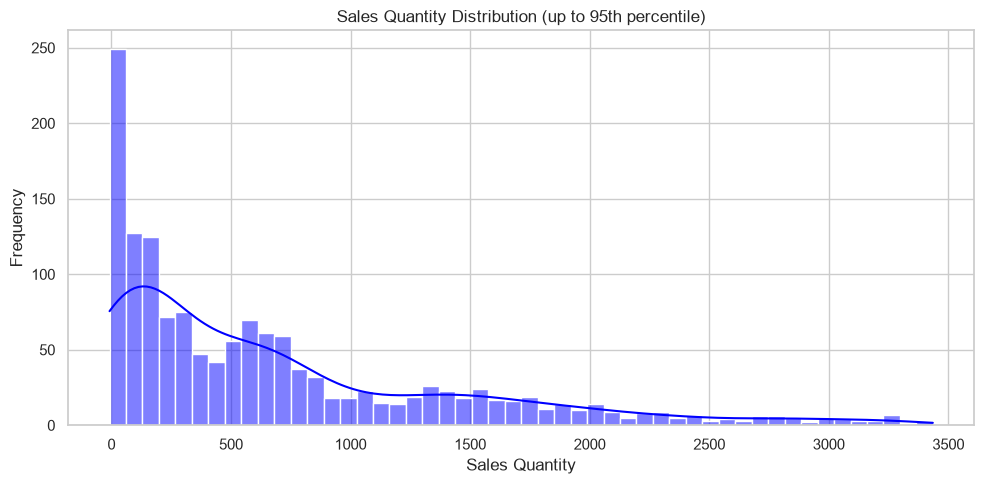

In [27]:
def plot_target_distribution(df, target_col='qty'):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 5))

    p95 = df[target_col].quantile(0.95)
    filtered_data = df[df[target_col] <= p95][target_col]

    sns.histplot(filtered_data, bins=50, kde=True, color='blue')
    plt.title('Sales Quantity Distribution (up to 95th percentile)')
    plt.xlabel('Sales Quantity')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()
    plt.close('all')

# Вызов на полной витрине
plot_target_distribution(df_full, 'qty')

Interesting observations from target distribution
* heavy zero-inflation with ~250 observations in the lowest bin highlights intermittent demand or slow-moving SKUs
* severe right-skew stretching up to 3,500 units confirms strong asymmetry and heteroscedasticity
* distinct secondary peaks around 600–700 and 1,300–1,500 units indicate distinct SKU velocity clusters

Baseline models to evaluate
* **Croston’s Method / TSB:** best suited for intermittent, zero-inflated SKUs by decoupling demand probability from size
* **Holt-Winters Exponential Smoothing:** standard baseline for regular SKUs exhibiting steady volume and seasonality
* **Weighted Moving Average (WMA):** robust, low-complexity benchmark to validate model performance uplift
* **LightGBM (Tweedie Loss):** optional lightweight ML approach to natively model zero-inflated, right-skewed data without log-transform bias

IQR Statistical Analysis (Global)
Feature: qty
Median: 509.50
IQR Range: 1122.25
Normal Boundaries: -1552.12 to 2936.88
Global Outliers Detected: 104 rows (6.82% of data)


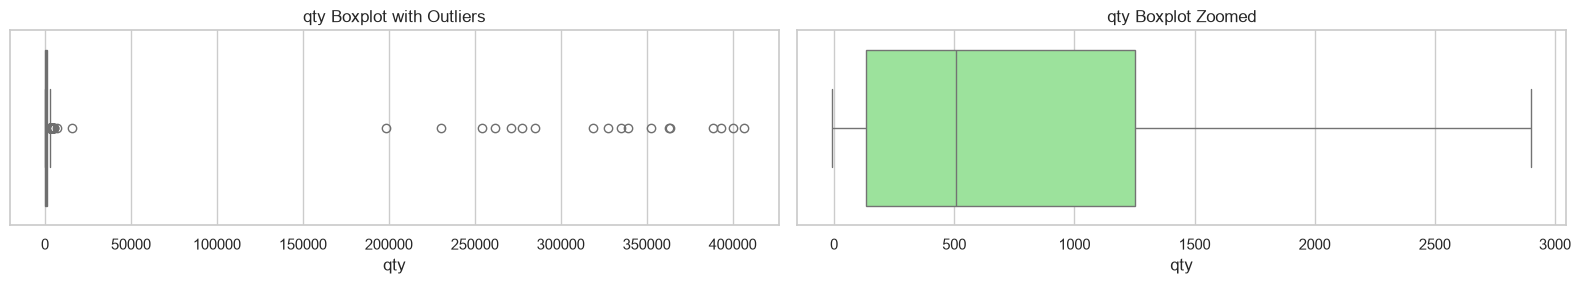

In [28]:
def analyze_outliers_iqr(df, column='qty'):
    print("IQR Statistical Analysis (Global)")

    if column not in df.columns:
        print(f"Column {column} not found.")
        return

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    total_outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]
    outlier_percentage = (total_outliers / df.shape[0]) * 100

    print(f"Feature: {column}")
    print(f"Median: {df[column].median():.2f}")
    print(f"IQR Range: {IQR:.2f}")
    print(f"Normal Boundaries: {lower_bound:.2f} to {upper_bound:.2f}")
    print(f"Global Outliers Detected: {total_outliers} rows ({outlier_percentage:.2f}% of data)")

    fig, axes = plt.subplots(1, 2, figsize=(16, 3))
    sns.boxplot(x=df[column], ax=axes[0], color='skyblue')
    axes[0].set_title(f'{column} Boxplot with Outliers')

    sns.boxplot(x=df[column], ax=axes[1], color='lightgreen', showfliers=False)
    axes[1].set_title(f'{column} Boxplot Zoomed')

    plt.tight_layout()
    plt.show()
    plt.close('all')

# Вызов на полной витрине
analyze_outliers_iqr(df_full, 'qty')

Interesting observations from global IQR analysis

The calculated lower limit of -1552.12 units is physically impossible for sales volume, proving global statistical limits fail on heavily skewed data.
* Labeling 6.82% of records as global outliers incorrectly flags high-volume A-class SKUs as anomalies simply due to baseline scale differences between items.
* An IQR range of 1122.25 reflects severe portfolio heteroscedasticity, making global thresholding completely unviable.

I will replace global IQR trimming entirely by targeted contextual cleaning. Smooth the 8 known `promo_calendar` periods using a rolling 3-month median of non-promo sales per SKU, hard-cap negative values at zero (`qty = max(0, qty)`), and preserve all organic non-promo peaks to avoid distorting real baseline demand.

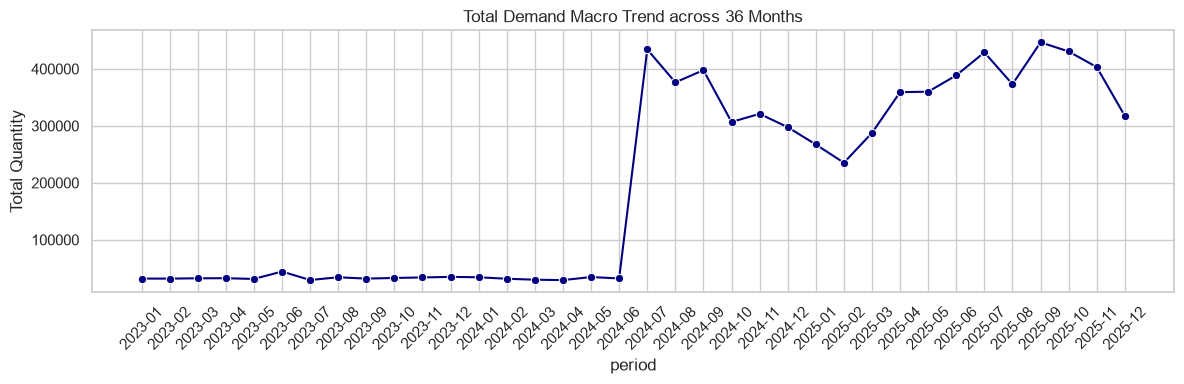

In [29]:
# Macro Dynamics & Seasonality
plt.figure(figsize=(12, 4))
macro_trend = df_full.groupby('period')['qty'].sum().reset_index()
sns.lineplot(data=macro_trend, x='period', y='qty', marker='o', color='navy')
plt.xticks(rotation=45)
plt.title('Total Demand Macro Trend across 36 Months')
plt.ylabel('Total Quantity')
plt.tight_layout()
plt.show()

In [30]:
# Average Demand Interval and Coefficient of Variation squared calculation
sku_stats = df_full.groupby('sku')['qty'].agg(
    total_periods='count',
    active_periods=lambda x: (x > 0).sum(),
    mean_qty='mean',
    std_qty='std'
).reset_index()

sku_stats['ADI'] = sku_stats['total_periods'] / sku_stats['active_periods']
sku_stats['CV2'] = (sku_stats['std_qty'] / sku_stats['mean_qty']) ** 2

def categorize_demand(row):
    if row['ADI'] < 1.32 and row['CV2'] < 0.49:
        return 'Smooth'
    elif row['ADI'] >= 1.32 and row['CV2'] < 0.49:
        return 'Intermittent'
    elif row['ADI'] < 1.32 and row['CV2'] >= 0.49:
        return 'Erratic'
    else:
        return 'Lumpy'

sku_stats['demand_type'] = sku_stats.apply(categorize_demand, axis=1)
print(sku_stats['demand_type'].value_counts())

demand_type
Smooth     33
Lumpy       6
Erratic     1
Name: count, dtype: int64


In [31]:
# Promo Uplift Analysis
promo_skus = df_full[df_full['discount_pct'] > 0]['sku'].unique()
promo_df = df_full[df_full['sku'].isin(promo_skus)].copy()
promo_df['is_promo'] = promo_df['discount_pct'] > 0

promo_uplift = promo_df.groupby(['sku', 'is_promo'])['qty'].mean().unstack()
promo_uplift.columns = ['regular_avg_qty', 'promo_avg_qty']
promo_uplift['uplift_pct'] = ((promo_uplift['promo_avg_qty'] - promo_uplift['regular_avg_qty']) / promo_uplift['regular_avg_qty']) * 100
print("Promo Uplift Analysis per SKU:")
display(promo_uplift)

Promo Uplift Analysis per SKU:


,regular_avg_qty,promo_avg_qty,uplift_pct
sku,,,
SKU_0001,287.764706,1165.5,305.018397
SKU_0006,124.000000,476.0,283.870968
SKU_0013,1657.628571,7202.0,334.476102
SKU_0020,3058.857143,15629.0,410.942462
SKU_0023,1474.114286,5279.0,258.113347
SKU_0028,139.542857,327.0,134.336609
SKU_0037,291.857143,1345.0,360.841899


In [32]:
#  Lost Sales Impact
# Calculate clean organic baseline median per SKU excluding promo and stockout periods
clean_baseline = df_full[(df_full['days_out_of_stock'] == 0) & (df_full['discount_pct'] == 0)]
sku_medians = clean_baseline.groupby('sku')['qty'].median()

# Define demand adjustment conditions and corresponding calculations
conditions = [
    df_full['days_out_of_stock'] == 0,
    (df_full['days_out_of_stock'] > 0) & (df_full['days_out_of_stock'] < 30)
]

choices = [
    np.maximum(0, df_full['qty']),
    (np.maximum(0, df_full['qty']) / (30 - df_full['days_out_of_stock'])) * 30
]

# For 100% OOS periods (days_out_of_stock >= 30), impute using clean organic SKU median
df_full['qty_restored'] = np.select(
    conditions,
    choices,
    default=df_full['sku'].map(sku_medians)
)

oos_records = df_full[df_full['days_out_of_stock'] > 0][['sku', 'location', 'period', 'days_out_of_stock', 'qty', 'qty_restored']].copy()
oos_records['lost_sales_est'] = (oos_records['qty_restored'] - oos_records['qty']).clip(lower=0).round(1)
print(f"Total estimated lost sales from OOS: {oos_records['lost_sales_est'].sum():.1f} units across {len(oos_records)} records")
display(oos_records)

Total estimated lost sales from OOS: 12987.0 units across 10 records


,sku,location,period,days_out_of_stock,qty,qty_restored,lost_sales_est
257,SKU_0007,MSK,2023-09,30,0,1466.5,1466.5
258,SKU_0007,MSK,2023-10,30,0,1466.5,1466.5
470,SKU_0012,MSK,2024-09,30,0,725.0,725.0
471,SKU_0012,MSK,2024-10,30,0,725.0,725.0
472,SKU_0012,MSK,2024-11,30,0,725.0,725.0
841,SKU_0021,MSK,2025-07,30,0,572.0,572.0
1268,SKU_0033,MSK,2024-03,30,0,3518.5,3518.5
1269,SKU_0033,MSK,2024-04,30,0,3518.5,3518.5
1443,SKU_0038,MSK,2025-02,30,0,135.0,135.0
1444,SKU_0038,MSK,2025-03,30,0,135.0,135.0


In [33]:
# History Completeness & Launch Period
history_completeness = df_full.groupby('sku').agg(
    total_months=('period', 'nunique'),
    zero_sales_months=('qty', lambda x: (x == 0).sum()),
    launch_period=('launch_period', 'first'),
    predecessor_sku=('predecessor_sku', 'first')
).reset_index()
print("SKU History Completeness Summary:")
display(history_completeness.head(10))

SKU History Completeness Summary:


,sku,total_months,zero_sales_months,launch_period,predecessor_sku
0,SKU_0001,36,0,2023-01,NaN
1,SKU_0002,36,27,2023-01,NaN
2,SKU_0003,36,0,2023-01,NaN
3,SKU_0004,36,0,2023-01,NaN
4,SKU_0005,32,0,2023-01,NaN
5,SKU_0006,36,0,2023-01,NaN
6,SKU_0007,36,2,2023-01,NaN
7,SKU_0008,36,0,2023-01,NaN
8,SKU_0009,36,26,2023-01,NaN
9,SKU_0010,36,0,2023-01,NaN


* I will use **Seasonal Naïve** and **Weighted Moving Average (WMA)** as the baseline floor to verify whether complex models deliver a real performance uplift over simple 12-month lags or 3-month rolling averages on pre-cleaned data.
* I will run **Holt-Winters Exponential Smoothing** as the primary engine on the 33 regular (Smooth) SKUs to directly capture baseline trend and annual seasonality on cleaned data.
* I will add **Auto-SARIMA** as an alternative statistical benchmark for Smooth SKUs to evaluate if automated $(p, d, q)(P, D, Q)_m$ parameter tuning captures residual autocorrelation better than exponential smoothing.
* I will select the **Teunter-Syntetos-Babai (TSB)** method over classic Croston for the 7 non-smooth (Lumpy/Erratic) SKUs, as TSB continuously updates demand probability every period and prevents severe over-forecasting after extended zero intervals.
* I will demote **LightGBM with Tweedie Loss** to an optional secondary experiment, as gradient boosting risks severe overfitting on a small dataset of just 1,440 rows ($40 \text{ SKUs} \times 36 \text{ months}$), despite its native ability to handle zero-inflation and right-skewed demand.